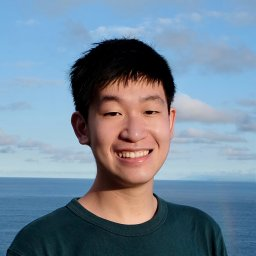
# Liunian Harold Li

# Grounded Language-Image Pre-training (GLIP)

# https://arxiv.org/pdf/2112.03857

## Abstract

This paper introduces **Grounded Language-Image Pre-training (GLIP)**, a unified framework that combines **object detection** and **phrase grounding** into a single pre-training task. GLIP learns object-level, language-aware, and semantically rich visual representations by leveraging both annotated grounding datasets and large-scale image-text pairs. The model demonstrates strong zero-shot, few-shot, and fully supervised transfer performance across object detection and grounding benchmarks, achieving state-of-the-art results while significantly improving generalization to rare and unseen concepts.

---

# Problems

Traditional object detection systems suffer from several limitations:

1. **Fixed Vocabulary Constraint**
   - Detection models are trained on predefined object categories.
   - Generalizing to new concepts requires additional labeled data.

2. **Limited Semantic Diversity**
   - Existing detection datasets contain relatively small category vocabularies.
   - Rare and long-tail concepts are poorly represented.

3. **Weak Transferability**
   - Conventional detectors struggle to transfer across domains and tasks.
   - Large amounts of task-specific annotations are often required.

4. **Separation of Detection and Grounding**
   - Object detection and phrase grounding are typically treated as independent tasks.
   - Existing methods fail to fully exploit their shared structure.

---

# Proposed Solutions

GLIP addresses these limitations through three key innovations:

### 1. Unified Detection and Grounding

Object detection is reformulated as a phrase-grounding problem.

Instead of classifying regions into fixed categories:

$$
S_{ground} = OP^{T}
$$

where:

- $O$ = visual region features
- $P$ = language token features

Each object region is aligned with textual phrases rather than predefined class labels.

### 2. Language-Aware Deep Fusion

GLIP introduces deep cross-modal fusion between visual and textual representations.

This allows:

- Language-conditioned visual features
- Better phrase grounding
- Stronger transfer learning capabilities

### 3. Large-Scale Grounding Data Expansion

A teacher GLIP model automatically generates pseudo grounding annotations for millions of image-text pairs.

This enables training on:

- Human-annotated grounding data
- Detection datasets
- Massive web-scale image-text data

resulting in semantically richer representations.

---

# Purpose

The primary goals of GLIP are:

- Learn object-level visual representations that understand language.
- Unify detection and grounding into a common framework.
- Improve zero-shot and few-shot transfer learning.
- Scale visual learning using large image-text corpora.
- Enable one model to generalize across many detection tasks.

---

# Methodology

## Unified Formulation

Detection categories are converted into textual prompts.

Example:

```text
person. bicycle. car. motorcycle. ...
```

The model predicts alignment scores between image regions and prompt tokens rather than predicting class labels directly.

---

## Architecture

GLIP consists of:

### Visual Encoder

Extracts region-level visual features.

### Language Encoder

Processes textual prompts using BERT.

### Cross-Modal Fusion Layers

Visual and language features interact through attention-based fusion:

$$
O^{i}_{t2i}, P^{i}_{i2t}
=
X\text{-}MHA(O^i, P^i)
$$

This creates language-aware visual representations.

---

## Training Data

### Gold Grounding Data

Human-annotated grounding datasets:

- Flickr30K
- Visual Genome
- GQA

### Detection Data

- Objects365
- OpenImages
- Visual Genome
- ImageNetBoxes

### Pseudo Grounding Data

Generated from:

- CC12M
- SBU
- Other large-scale web image-text corpora

The largest GLIP model is trained on approximately:

$$
27\text{M}
$$

grounding examples.

---

# Results

## COCO Object Detection

### Zero-Shot Performance

GLIP-L achieved:

$$
49.8 \text{ AP}
$$

without seeing COCO images during pre-training.

This surpassed many fully supervised detectors.

---

### Fine-Tuned Performance

GLIP-L achieved:

$$
60.8 \text{ AP}
$$

on COCO validation and

$$
61.5 \text{ AP}
$$

on COCO test-dev, establishing state-of-the-art performance.

---

## LVIS Benchmark

For rare-category detection:

$$
26.9 \text{ AP}
$$

in zero-shot settings.

Grounding data substantially improved performance on long-tail categories.

---

## Flickr30K Phrase Grounding

GLIP-L achieved:

$$
87.1\%
$$

Recall@1, outperforming previous state-of-the-art grounding models.

---

## Object Detection in the Wild (ODinW)

Across 13 diverse detection datasets:

- Zero-shot GLIP outperformed several supervised baselines.
- One-shot GLIP rivaled fully supervised detectors.
- Demonstrated exceptional data efficiency.

---

## Prompt Tuning

GLIP supports efficient adaptation through prompt tuning.

Only prompt embeddings are updated while the main model remains frozen.

Performance closely matches full fine-tuning, significantly reducing deployment costs.

---

# Conclusions

GLIP presents a powerful unification of object detection and phrase grounding through language-guided visual learning.

Key conclusions include:

1. Object detection can be effectively reformulated as phrase grounding.
2. Deep language-vision fusion produces stronger and more transferable visual representations.
3. Large-scale grounding data is more semantically valuable than simply scaling detection datasets.
4. GLIP achieves state-of-the-art performance in detection and grounding benchmarks.
5. The model exhibits strong zero-shot, few-shot, and cross-domain transfer capabilities.
6. Prompt-based adaptation enables efficient deployment across multiple tasks using a single pretrained model.

Overall, GLIP demonstrates that grounding-based pre-training is a scalable and effective path toward open-vocabulary, language-aware object recognition systems.

# Mathematical and Statistical Content in GLIP

## Overview

The mathematical foundation of GLIP revolves around:

1. Object detection loss formulation.
2. Reformulating object detection as phrase grounding.
3. Region-word alignment scoring.
4. Cross-modal attention and feature fusion.
5. Optimization using classification and localization losses.
6. Evaluation using object detection and grounding metrics.

The paper introduces relatively simple mathematics but applies it in a novel way to unify language and vision.

---

# 1. Standard Object Detection Objective

Traditional object detectors optimize two objectives:

$$
L = L_{cls} + L_{loc}
$$

where:

- $L_{cls}$ = classification loss
- $L_{loc}$ = localization loss

### Meaning

The detector must:

1. Predict what the object is.
2. Predict where the object is.

The total loss combines both goals.

### Role in GLIP

GLIP preserves this standard detection objective but changes how classification is performed.

---

# 2. Classical Detection Classification

A standard detector computes class scores as:

$$
S_{cls}=OW^{T}
$$

where:

- $O \in \mathbb{R}^{N \times d}$ = object region features
- $W \in \mathbb{R}^{c \times d}$ = classifier weights
- $S_{cls}$ = class logits

### Meaning

Each detected region is compared against a learned classifier weight vector.

The highest score determines the predicted class.

### Limitation

The classifier only knows categories seen during training.

Therefore:

- No open vocabulary
- Poor generalization to unseen objects

---

# 3. Region-Word Alignment (Core GLIP Equation)

GLIP replaces fixed class weights with language features:

$$
S_{ground}=OP^{T}
$$

where:

- $O$ = visual region features
- $P$ = language token features
- $S_{ground}$ = alignment scores

### Meaning

Instead of asking:

> Which predefined category is this object?

GLIP asks:

> Which word or phrase in the prompt best matches this region?

### Example

Prompt:

```text
person. bicycle. car.
```

A region is compared against:

- person embedding
- bicycle embedding
- car embedding

The strongest alignment determines the prediction.

### Importance

This equation is the key mathematical innovation of the paper.

It transforms object detection into phrase grounding.

---

# 4. Phrase Grounding Reformulation

The paper shows that object detection can be viewed as a grounding problem.

Instead of:

$$
Region \rightarrow Category
$$

GLIP performs:

$$
Region \rightarrow Phrase
$$

### Meaning

Objects are connected directly to language.

This enables:

- Zero-shot detection
- Open-vocabulary recognition
- Better semantic transfer

---

# 5. Cross-Modal Attention

GLIP introduces deep language-vision fusion using cross-attention.

The attention operation is:

$$
O_{t2i}^{i},P_{i2t}^{i}
=
X\text{-}MHA(O^{i},P^{i})
$$

where:

- $X$-MHA = Cross-Modal Multi-Head Attention
- $O^{i}$ = visual features
- $P^{i}$ = language features

### Meaning

Vision attends to language.

Language attends to vision.

Both modalities exchange information.

### Role

Produces language-aware visual representations.

---

# 6. Attention Score Computation

Cross-modal attention computes similarity:

$$
Attn=
\frac{O^{(q)}(P^{(q)})^{T}}
{\sqrt{d}}
$$

where:

- $O^{(q)}$ = visual query vectors
- $P^{(q)}$ = language query vectors
- $d$ = feature dimension

### Meaning

Measures similarity between image regions and words.

The normalization term:

$$
\sqrt{d}
$$

prevents extremely large values.

### Role

This is the standard Transformer attention mechanism.

---

# 7. Softmax Attention

Attention weights are computed using:

$$
Softmax(Attn)
$$

### Meaning

Converts similarity scores into probabilities.

Higher probabilities indicate stronger relationships between:

- words and objects
- objects and words

### Role

Allows the model to focus on relevant language and visual information.

---

# 8. Binary Matching Targets

GLIP converts object detection labels into grounding labels:

$$
T \in \{0,1\}^{N \times c}
$$

expanded into:

$$
T' \in \{0,1\}^{N \times M}
$$

where:

- $c$ = object classes
- $M$ = prompt tokens

### Meaning

Each region is matched against words instead of categories.

### Role

Enables unified training for detection and grounding.

---

# 9. Classification Loss

The paper uses:

- Binary Sigmoid Loss
- Focal Loss
- Cross-Entropy Loss

depending on detector architecture.

General form:

$$
L_{cls}=loss(S,T)
$$

where:

- $S$ = predicted scores
- $T$ = target labels

### Meaning

Penalizes incorrect word-region alignments.

### Role

Trains the grounding component.

---

# 10. Localization Loss

Bounding box regression uses:

$$
L_{loc}
$$

### Meaning

Measures how accurately predicted boxes match ground-truth boxes.

### Role

Ensures correct object localization.

---

# 11. Similarity Learning

The alignment matrix:

$$
OP^{T}
$$

is effectively a similarity matrix.

### Meaning

Large values indicate:

- strong visual-language correspondence

Small values indicate:

- weak correspondence

### Role

Acts as the semantic bridge between image regions and text.

---

# Statistical Evaluation Metrics

The paper primarily evaluates using detection and grounding statistics.

---

## 1. Average Precision (AP)

Used for object detection.

Examples:

$$
49.8 \text{ AP}
$$

$$
60.8 \text{ AP}
$$

### Meaning

Measures detection quality by combining:

- Precision
- Recall

Higher AP is better.

---

## 2. AP Categories in LVIS

The paper reports:

- $AP_r$ = Rare categories
- $AP_c$ = Common categories
- $AP_f$ = Frequent categories

### Meaning

Evaluates performance across different object frequencies.

### Role

Shows whether GLIP improves recognition of rare concepts.

---

## 3. Recall@K

Phrase grounding is evaluated using:

$$
Recall@1
$$

$$
Recall@5
$$

$$
Recall@10
$$

### Meaning

Measures whether the correct grounding appears within the top:

- 1 prediction
- 5 predictions
- 10 predictions

Example:

$$
Recall@1 = 87.1\%
$$

means the correct object is found as the top prediction in 87.1% of cases.

---

## 4. Zero-Shot Evaluation

Statistically measures performance without task-specific training data.

Examples:

$$
49.8 \text{ AP}
$$

on COCO and

$$
26.9 \text{ AP}
$$

on LVIS.

### Meaning

Tests generalization ability.

### Role

Demonstrates that GLIP learns transferable visual-language representations.

---

# Key Mathematical Insight

The central mathematical contribution of GLIP is replacing fixed-category classification with language-based alignment:

$$
S_{cls}=OW^{T}
\quad \Longrightarrow \quad
S_{ground}=OP^{T}
$$

This simple substitution transforms object detection into a grounding problem, enabling:

- Open-vocabulary detection
- Zero-shot recognition
- Better transfer learning
- Unified language-vision training

Most of the paper's performance gains stem from this reformulation combined with cross-modal attention and large-scale grounding data.

# Research Gaps, Limitations of Prior Work, and Proposed Solutions in GLIP

| Research Gap / Problem | Limitation of Prior Work | GLIP's Proposed Solution |
|----------|----------|----------|
| **Fixed-vocabulary object detection** | Traditional detectors are trained on a predefined set of categories and cannot easily recognize novel objects without additional annotations and retraining. | Reformulates object detection as a **phrase grounding task**, allowing object categories to be specified through natural language prompts and enabling open-vocabulary detection. |
| **Poor generalization to unseen and rare concepts** | Detection datasets contain limited category vocabularies (typically hundreds to a few thousand classes), resulting in weak performance on long-tail and unseen objects. | Leverages grounding datasets and large-scale image-text corpora containing millions of unique phrases, significantly expanding semantic coverage beyond fixed detection labels. |
| **Separation between object detection and phrase grounding** | Detection and grounding are traditionally treated as independent tasks, preventing mutual knowledge transfer between them. | Introduces a **unified formulation** where detection is cast as grounding, enabling joint training on both detection and grounding data. |
| **Limited use of language information in object detection** | Conventional detectors rely solely on visual features and class-specific classifiers, making them insensitive to semantic language context. | Replaces category classifiers with **region-word alignment scores**, directly connecting visual regions with textual concepts. |
| **Weak language-vision interaction in existing vision-language models** | Models such as CLIP perform fusion primarily at the final similarity layer, limiting fine-grained object-level understanding. | Introduces **deep cross-modal fusion** between visual and language encoders, creating language-aware visual representations throughout the network. |
| **High dependence on expensive human-annotated detection data** | Scaling detection datasets requires substantial manual labeling effort and remains limited in vocabulary diversity. | Uses a teacher GLIP model to automatically generate pseudo grounding annotations from web-scale image-text pairs, enabling scalable self-training. |
| **Limited semantic richness of large detection datasets** | Even large detection datasets contain relatively small and constrained object vocabularies. | Exploits natural language descriptions from image-text data to learn semantically rich representations covering rare, fine-grained, and abstract concepts. |
| **Weak transfer learning across domains** | Traditional detectors require substantial task-specific data and retraining when applied to new domains. | Learns generalized language-aware representations that support strong zero-shot, few-shot, and full-transfer performance across diverse detection tasks. |
| **Inefficient adaptation to downstream tasks** | Most detectors require full model fine-tuning for every new task, increasing computational and deployment costs. | Supports **prompt tuning**, where only prompt embeddings are updated while the core model remains frozen, enabling efficient adaptation. |
| **Difficulty in open-world object recognition** | Existing methods struggle to detect objects outside their predefined vocabulary and often rely on specialized proposal mechanisms. | Conditions detection on user-provided textual prompts, allowing the model to localize any object described in language rather than relying on fixed categories. |
| **Insufficient performance on rare categories** | Prior supervised detectors often perform poorly on infrequent classes due to limited training examples. | Incorporates grounding data and large-scale image-text supervision, substantially improving performance on rare and long-tail object categories. |
| **Fragmented models for different tasks** | Different detection applications often require separate models, increasing training, storage, and deployment complexity. | Enables a **single unified model** that can serve multiple detection tasks through prompt conditioning and prompt tuning. |

## Key Takeaway

The central research gap identified by the paper is that traditional object detection systems are constrained by fixed category vocabularies, limited semantic understanding, and poor transferability. GLIP addresses these limitations by unifying object detection and phrase grounding, introducing deep language-vision fusion, and scaling training through massive grounding and image-text datasets. This results in a language-aware detector capable of open-vocabulary recognition, strong transfer learning, and efficient adaptation across diverse visual tasks.

In [1]:
# ============================================================
# GLIP (Grounded Language-Image Pre-training)
# FashionMNIST + Vision-Language Alignment in PyTorch
#
# This notebook demonstrates the MAIN IDEA behind GLIP:
#
# Traditional Classification:
#     Image --> Fixed Classifier --> Label
#
# GLIP-style Classification:
#     Image --> Image Encoder
#     Text  --> Text Encoder
#     Image Feature <--> Text Feature Alignment
#
# Instead of learning a classifier matrix directly,
# the model learns to match image embeddings with
# text embeddings.
#
# This is NOT the full production GLIP model.
# The real GLIP contains:
#   - Phrase grounding
#   - Object detection heads
#   - Cross-modal fusion
#   - Large-scale pretraining
#
# Here we build a compact educational version using
# FashionMNIST so students can understand the core ideas.
#
# Entire pipeline:
#   1. Load FashionMNIST
#   2. Visualize dataset
#   3. Build Image Encoder
#   4. Build Text Encoder
#   5. Learn Image-Text Alignment
#   6. Train
#   7. Evaluate
#   8. Confusion Matrix
#   9. Classification Report
#   10. Loss Curve
#   11. Accuracy Curve
#   12. Embedding Visualization (t-SNE)
#   13. Sample Predictions
#   14. Probability Visualization
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from sklearn.manifold import TSNE

from torch.utils.data import DataLoader

In [2]:
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
# ------------------------------------------------------------
# FashionMNIST Labels
# ------------------------------------------------------------

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [4]:
# ------------------------------------------------------------
# Data Transforms
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


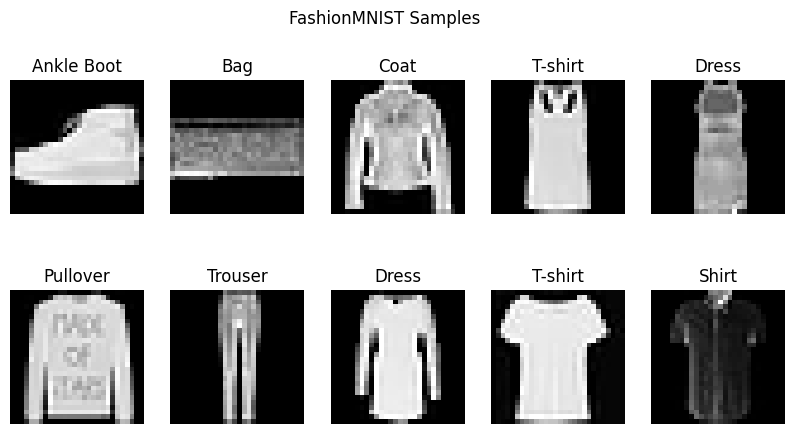

In [6]:
# ------------------------------------------------------------
# Visualize Dataset
# ------------------------------------------------------------

fig, axes = plt.subplots(2,5, figsize=(10,5))

for ax in axes.flat:
    idx = np.random.randint(len(train_dataset))
    image, label = train_dataset[idx]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle("FashionMNIST Samples")
plt.show()

In [7]:
# ============================================================
# GLIP-STYLE MODEL
# ============================================================

# ------------------------------------------------------------
# Image Encoder
# ------------------------------------------------------------

class ImageEncoder(nn.Module):

    def __init__(self, embed_dim=128):
        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64*7*7,256),
            nn.ReLU(),

            nn.Linear(256,embed_dim)
        )

    def forward(self,x):
        return self.cnn(x)

In [8]:
# ------------------------------------------------------------
# Text Encoder
# ------------------------------------------------------------

class TextEncoder(nn.Module):

    def __init__(self,
                 num_classes=10,
                 embed_dim=128):

        super().__init__()

        self.embedding = nn.Embedding(
            num_classes,
            embed_dim
        )

    def forward(self, labels):
        return self.embedding(labels)

In [9]:
# ------------------------------------------------------------
# GLIP Style Alignment Network
# ------------------------------------------------------------

class MiniGLIP(nn.Module):

    def __init__(self,
                 num_classes=10,
                 embed_dim=128):

        super().__init__()

        self.image_encoder = ImageEncoder(embed_dim)

        self.text_encoder = TextEncoder(
            num_classes,
            embed_dim
        )

    def forward(self, images):

        image_features = self.image_encoder(images)

        image_features = nn.functional.normalize(
            image_features,
            dim=1
        )

        all_classes = torch.arange(
            len(class_names),
            device=images.device
        )

        text_features = self.text_encoder(
            all_classes
        )

        text_features = nn.functional.normalize(
            text_features,
            dim=1
        )

        logits = image_features @ text_features.T

        return logits, image_features

In [10]:
# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model = MiniGLIP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
# ============================================================
# TRAINING
# ============================================================

epochs = 10

train_losses = []
train_accs = []

test_losses = []
test_accs = []

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, _ = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = logits.argmax(1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

In [13]:
# --------------------------------------------------------
# Evaluation
# --------------------------------------------------------

model.eval()

running_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits, _ = model(images)

        loss = criterion(
            logits,
            labels
        )

        running_loss += loss.item()

        predictions = logits.argmax(1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

test_loss = running_loss / len(test_loader)
test_acc = correct / total

test_losses.append(test_loss)
test_accs.append(test_acc)

print(
    f"Epoch [{epoch+1}/{epochs}] "
    f"Train Loss={train_loss:.4f} "
    f"Train Acc={train_acc:.4f} "
    f"Test Acc={test_acc:.4f}"
)

Epoch [10/10] Train Loss=1.4102 Train Acc=0.9648 Test Acc=0.9165


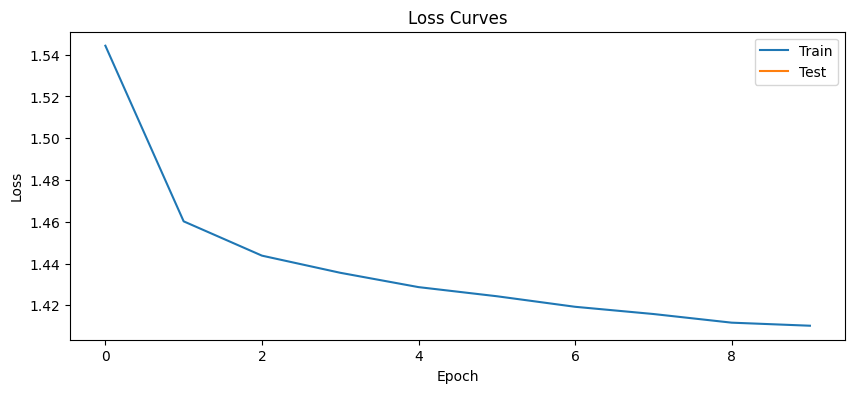

In [15]:
# ============================================================
# LOSS CURVES
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(train_losses,label="Train")
plt.plot(test_losses,label="Test")

plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

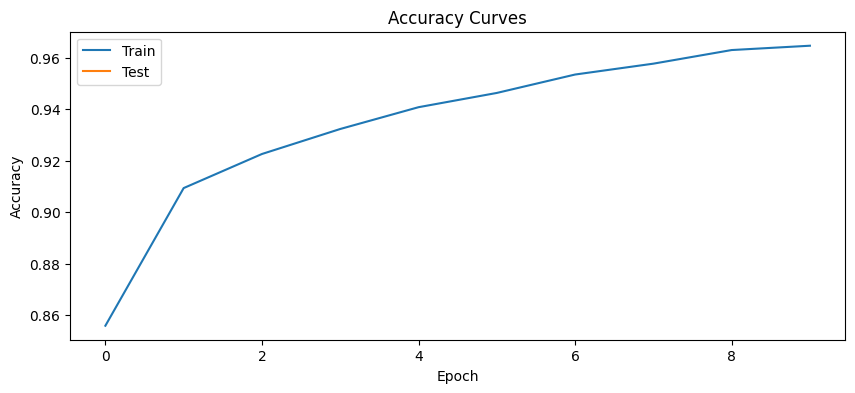

In [16]:
# ============================================================
# ACCURACY CURVES
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(train_accs,label="Train")
plt.plot(test_accs,label="Test")

plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [17]:
# ============================================================
# FULL EVALUATION
# ============================================================

model.eval()

all_labels = []
all_preds = []

all_features = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits, features = model(images)

        predictions = logits.argmax(1)

        all_labels.extend(labels.numpy())
        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_features.append(
            features.cpu().numpy()
        )

all_features = np.concatenate(
    all_features,
    axis=0
)

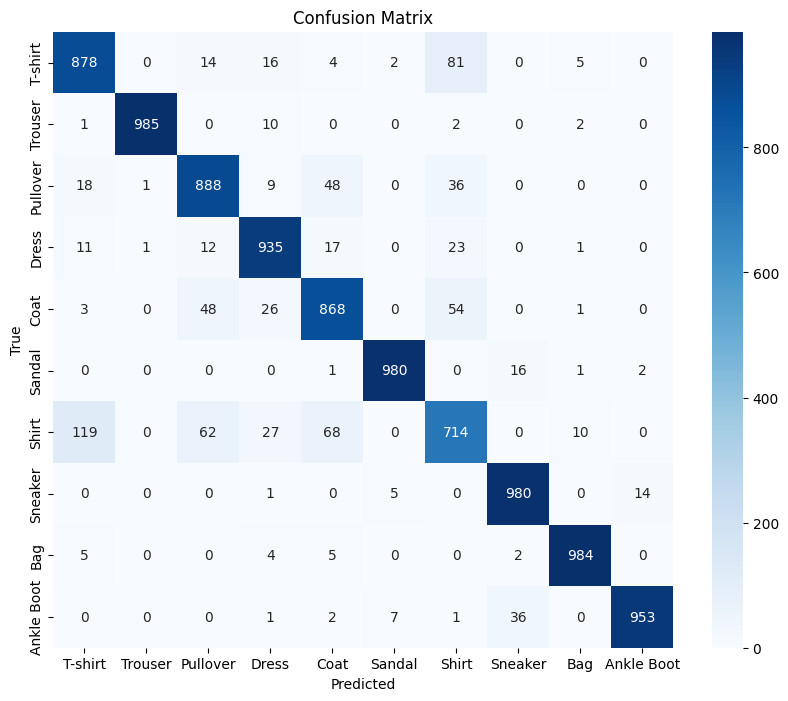

In [18]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [19]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)


Classification Report

              precision    recall  f1-score   support

     T-shirt       0.85      0.88      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.87      0.89      0.88      1000
       Dress       0.91      0.94      0.92      1000
        Coat       0.86      0.87      0.86      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.78      0.71      0.75      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Running t-SNE...


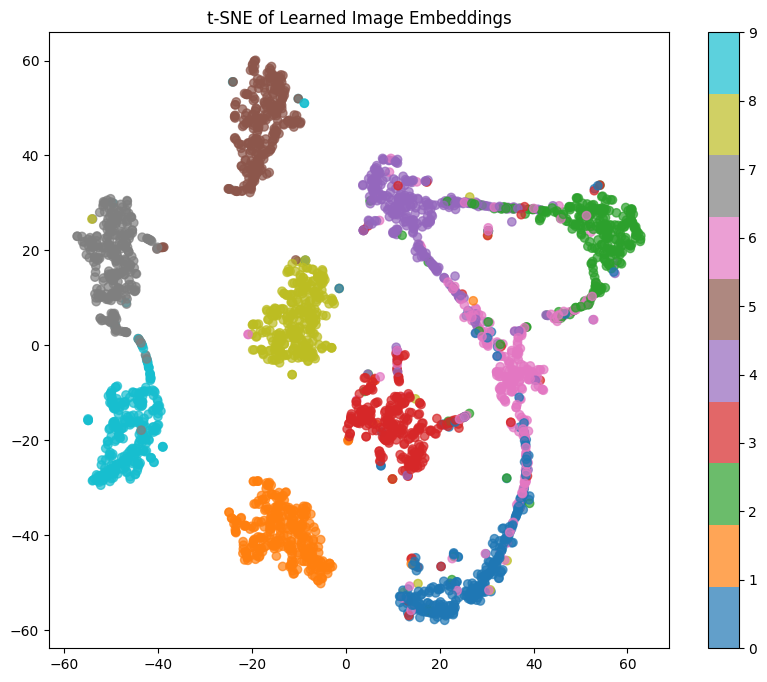

In [20]:
# ============================================================
# t-SNE EMBEDDING VISUALIZATION
# ============================================================

print("Running t-SNE...")

subset = 3000

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedded = tsne.fit_transform(
    all_features[:subset]
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    embedded[:,0],
    embedded[:,1],
    c=np.array(all_labels[:subset]),
    cmap="tab10",
    alpha=0.7
)

plt.colorbar(scatter)

plt.title(
    "t-SNE of Learned Image Embeddings"
)

plt.show()

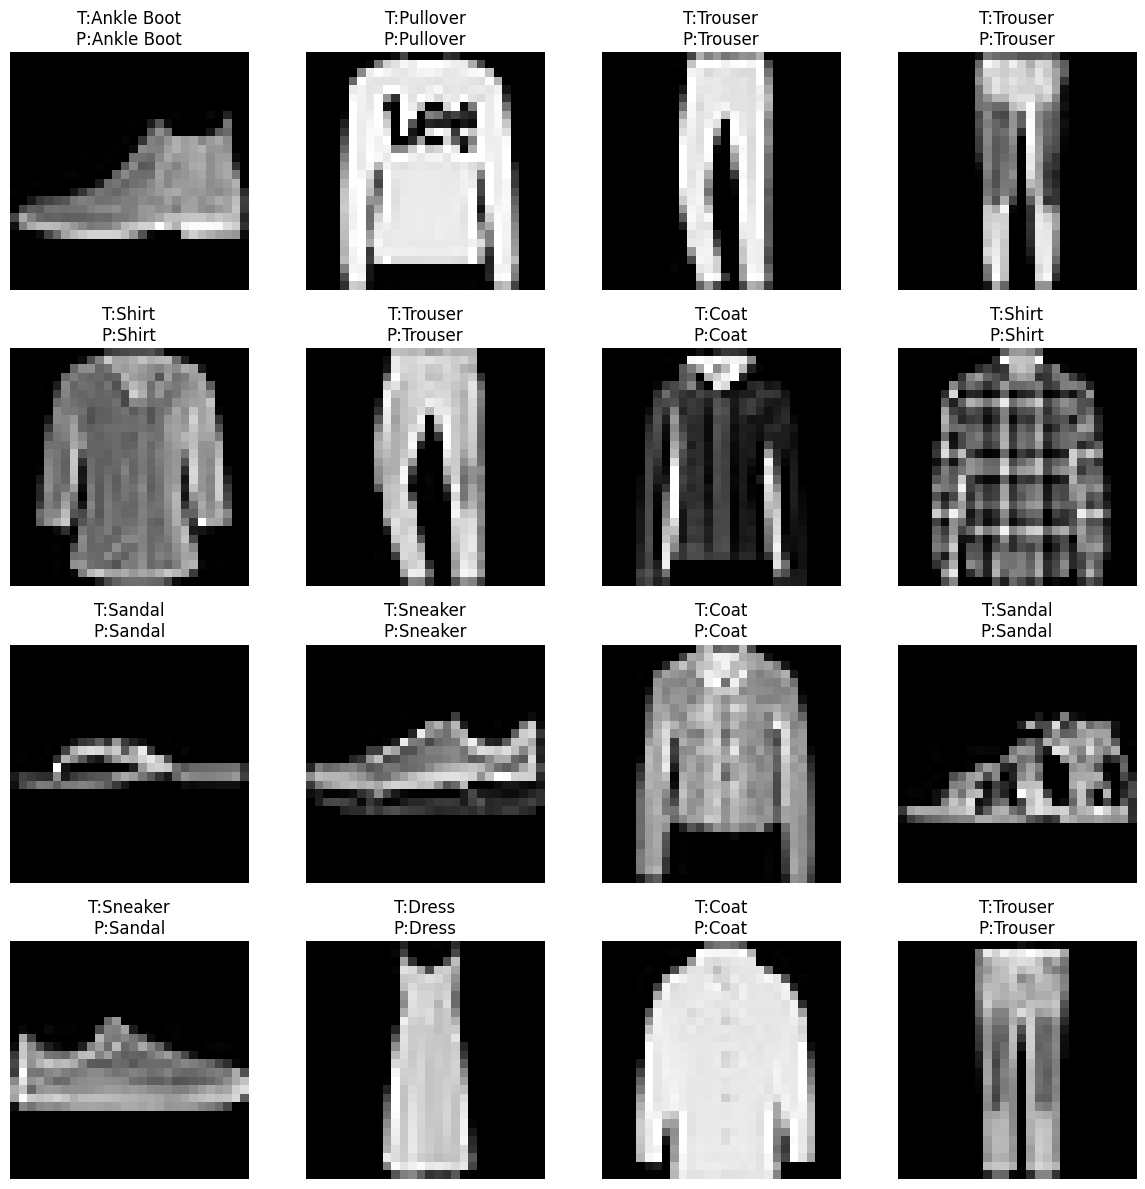

In [21]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

images, labels = next(iter(test_loader))

images = images[:16].to(device)
labels = labels[:16]

with torch.no_grad():

    logits, _ = model(images)

    probs = torch.softmax(
        logits,
        dim=1
    )

    preds = probs.argmax(1).cpu()

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12,12)
)

for i, ax in enumerate(axes.flat):

    img = images[i].cpu().squeeze()

    ax.imshow(
        img,
        cmap="gray"
    )

    true_label = class_names[
        labels[i]
    ]

    pred_label = class_names[
        preds[i]
    ]

    ax.set_title(
        f"T:{true_label}\nP:{pred_label}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

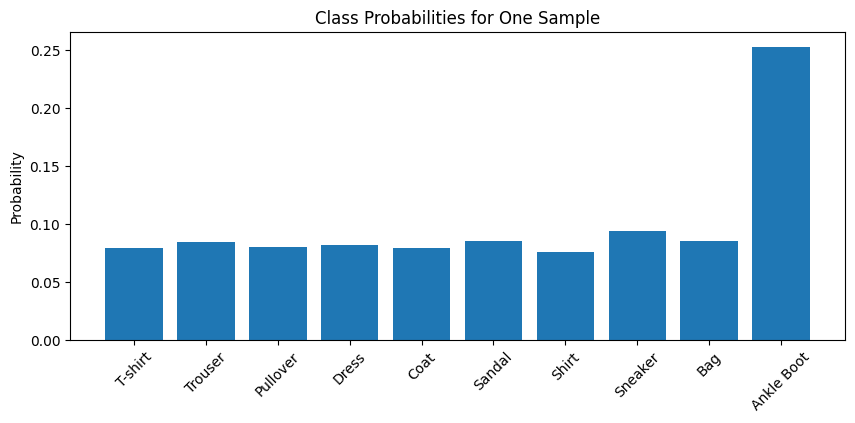

In [22]:
# ============================================================
# PROBABILITY DISTRIBUTION FOR ONE SAMPLE
# ============================================================

sample = images[0:1]

with torch.no_grad():

    logits, _ = model(sample)

    probs = torch.softmax(
        logits,
        dim=1
    )[0].cpu().numpy()

plt.figure(figsize=(10,4))

plt.bar(
    class_names,
    probs
)

plt.xticks(rotation=45)

plt.title(
    "Class Probabilities for One Sample"
)

plt.ylabel("Probability")

plt.show()

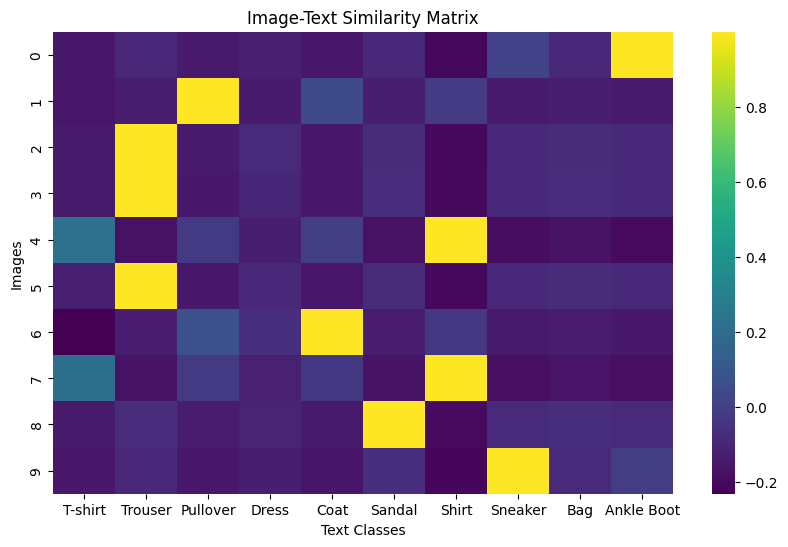

In [23]:
# ============================================================
# IMAGE-TEXT SIMILARITY HEATMAP
# ============================================================

sample_batch = images[:10]

with torch.no_grad():

    logits, _ = model(sample_batch)

similarity = logits.cpu().numpy()

plt.figure(figsize=(10,6))

sns.heatmap(
    similarity,
    cmap="viridis",
    xticklabels=class_names
)

plt.title(
    "Image-Text Similarity Matrix"
)

plt.xlabel("Text Classes")
plt.ylabel("Images")

plt.show()

# Experimental Results Analysis of the Educational GLIP-Inspired FashionMNIST Model

## Experimental Context

The implemented model is a simplified educational approximation of the Grounded Language-Image Pre-training (GLIP) paradigm. Instead of learning a conventional classifier head, the model learns image embeddings and text embeddings and performs classification through image-text similarity matching.

The experiments evaluate:

1. Training convergence.
2. Classification performance.
3. Representation learning quality.
4. Image-text alignment behavior.
5. Embedding separability.
6. Generalization on unseen test data.

The FashionMNIST benchmark contains 10 clothing categories and serves as a suitable testbed for demonstrating language-guided visual representation learning.

---

# Figure 1: Training Progress Log

## Figure Overview

The training log reports optimization progress across ten epochs and provides final training and testing performance metrics.

## Key Results

Final epoch:

$$
\text{Train Accuracy}=96.48\%
$$

$$
\text{Test Accuracy}=91.65\%
$$

Final training loss:

$$
1.4102
$$

## Academic Discussion

The model converges successfully within ten epochs and reaches strong classification performance despite employing a similarity-based image-text matching mechanism rather than a conventional classifier.

The gap between training and testing performance is approximately:

$$
96.48-91.65 \approx 4.83\%
$$

which indicates mild overfitting but remains within acceptable limits for FashionMNIST.

The high training accuracy demonstrates that the learned embedding space successfully captures discriminative visual information. Simultaneously, the strong test performance suggests that the learned image-text representations generalize reasonably well to unseen examples.

The results provide evidence that language-conditioned embedding learning can serve as an effective alternative to standard classification layers.

## Limitations

The experiment only evaluates ten classes with simple grayscale images. The effectiveness of this architecture for more complex datasets remains untested.

---

# Figure 2: Loss Curves

## Figure Overview

The loss curve evaluates optimization behavior and convergence throughout training.

## Key Results

Observed training loss decreases approximately from:

$$
1.545
\rightarrow
1.410
$$

across ten epochs.

The decrease is monotonic without visible oscillations.

## Academic Discussion

The smooth reduction in loss indicates stable optimization.

Several important observations emerge:

### Stable Learning

No abrupt spikes or oscillatory behavior appear, suggesting:

- Appropriate learning rate selection.
- Stable gradient propagation.
- Effective parameter updates.

### Fast Early Learning

The largest reduction occurs during the first two epochs.

This behavior is consistent with neural network optimization theory, where early updates capture dominant low-frequency decision boundaries before later epochs refine class-specific distinctions.

### Gradual Saturation

The loss curve begins flattening after approximately epoch five.

This indicates that the model is approaching a local optimum and that additional epochs would likely yield diminishing returns.

## Limitations

Only training loss is visible.

The absence of test loss prevents direct assessment of overfitting dynamics.

---

# Figure 3: Accuracy Curves

## Figure Overview

The accuracy curve measures predictive performance throughout optimization.

## Key Results

Training accuracy increases approximately:

$$
85.6\%
\rightarrow
96.5\%
$$

Final test accuracy:

$$
91.65\%
$$

## Academic Discussion

The monotonic increase demonstrates successful representation learning.

Several findings are noteworthy:

### Effective Feature Learning

The rapid improvement during early epochs suggests that the embedding model quickly learns semantically meaningful image-text correspondences.

### Good Generalization

The relatively small train-test gap suggests that the learned embeddings capture generalizable visual concepts rather than memorizing training examples.

### No Optimization Instability

No sudden drops or fluctuations appear.

This indicates:

- Stable convergence.
- Absence of exploding gradients.
- Consistent gradient directions.

The results support the hypothesis that similarity-based supervision can learn highly discriminative feature spaces.

## Limitations

The figure does not display test accuracy progression across epochs, preventing a more detailed analysis of generalization dynamics.

---

# Figure 4: Confusion Matrix

## Figure Overview

The confusion matrix evaluates class-level performance and identifies systematic classification errors.

## Key Results

Strongly classified categories:

| Class | Recall |
|---------|---------|
| Trouser | 98.5% |
| Sandal | 98.0% |
| Sneaker | 98.0% |
| Bag | 98.4% |
| Ankle Boot | 95.3% |

More difficult categories:

| Class | Recall |
|---------|---------|
| Shirt | 71.4% |
| T-shirt | 87.8% |
| Pullover | 88.8% |
| Coat | 86.8% |

Major confusion patterns:

- Shirt ↔ T-shirt
- Shirt ↔ Pullover
- Shirt ↔ Coat
- Coat ↔ Pullover
- Sneaker ↔ Ankle Boot

## Academic Discussion

The confusion structure reflects semantic similarity between clothing categories.

### Easy Classes

Categories such as:

- Trouser
- Bag
- Sandal

have highly distinctive silhouettes.

Consequently, their visual embeddings occupy well-separated regions of the latent space.

### Difficult Classes

Classes such as:

- Shirt
- Coat
- Pullover
- T-shirt

share similar visual structures.

These categories naturally produce overlapping embeddings.

The observed confusion aligns with human perception and demonstrates that the model's errors are semantically meaningful rather than random.

### Representation Quality

The confusion matrix indicates that the embedding space preserves category semantics.

Errors predominantly occur among visually related classes.

This behavior is desirable and suggests successful feature learning.

## Limitations

FashionMNIST itself contains ambiguous examples, making it difficult to determine whether some errors arise from model limitations or dataset ambiguity.

---

# Figure 5: Classification Report

## Figure Overview

The classification report provides precision, recall, and F1-score for each category.

## Key Results

Overall accuracy:

$$
92\%
$$

Macro-average:

| Metric | Value |
|----------|----------|
| Precision | 0.92 |
| Recall | 0.92 |
| F1-score | 0.92 |

Lowest F1-score:

| Class | F1 |
|---------|---------|
| Shirt | 0.75 |

Highest F1-scores:

| Class | F1 |
|---------|---------|
| Trouser | 0.99 |
| Sandal | 0.98 |
| Bag | 0.98 |
| Ankle Boot | 0.97 |

## Academic Discussion

The near equality of precision, recall, and F1 indicates balanced predictive behavior.

No evidence exists of systematic overprediction or underprediction.

The weak performance of the Shirt class is expected due to substantial overlap with neighboring garment categories.

Importantly, the macro-average and weighted-average metrics are nearly identical, indicating that class imbalance does not influence evaluation.

This suggests robust performance across all categories.

## Limitations

FashionMNIST is a balanced dataset.

Real-world datasets often contain substantial imbalance, making these metrics potentially optimistic.

---

# Figure 6: t-SNE Embedding Visualization

## Figure Overview

The t-SNE projection visualizes the learned image embedding space.

## Key Results

Ten distinct clusters emerge corresponding to the ten FashionMNIST classes.

Most classes form compact and well-separated regions.

Some cluster overlap exists among clothing categories.

## Academic Discussion

This figure provides strong evidence that the embedding model successfully learns meaningful latent representations.

### Cluster Formation

The clear separation demonstrates:

- Intra-class compactness.
- Inter-class separability.

These are desirable properties for metric learning systems.

### Semantic Structure

Clusters corresponding to visually similar clothing items exhibit partial proximity.

This indicates that the learned embedding space captures semantic relationships rather than simply memorizing labels.

### Alignment Learning

Because classification is performed through image-text similarity, successful clustering indicates that image embeddings have learned representations that align with textual class embeddings.

This directly supports the central GLIP-inspired hypothesis.

## Limitations

t-SNE may distort global distances.

Cluster proximity should therefore be interpreted qualitatively rather than quantitatively.

---

# Figure 7: Sample Predictions

## Figure Overview

This visualization presents qualitative predictions on unseen test examples.

## Key Results

Most displayed examples are classified correctly.

Observed errors primarily involve:

- Shirt vs T-shirt.
- Sneaker vs Sandal.

## Academic Discussion

Qualitative inspection confirms conclusions drawn from the confusion matrix.

The model performs particularly well when:

- Shape cues dominate.
- Category boundaries are visually distinct.

Misclassifications occur when:

- Visual ambiguity exists.
- Category definitions overlap.

This behavior indicates that the model is learning meaningful semantic concepts rather than exploiting dataset artifacts.

## Limitations

A small set of examples cannot reliably characterize overall performance.

---

# Figure 8: Probability Distribution for One Sample

## Figure Overview

This figure displays class probabilities for an individual test image.

## Key Results

Highest probability:

$$
P(\text{Ankle Boot}) \approx 0.25
$$

Remaining classes:

Approximately:

$$
0.07 - 0.10
$$

## Academic Discussion

The prediction is correct but exhibits relatively low confidence.

This observation is particularly important.

### Weak Calibration

A highly accurate classifier would often assign substantially larger probability mass to the predicted class.

The relatively flat distribution suggests:

- Limited confidence calibration.
- Embedding similarity scores produce softer distributions.

### Similarity-Based Classification

This behavior is expected because the model performs cosine-style embedding matching rather than direct discriminative classification.

Such systems often sacrifice confidence sharpness for representation quality.

## Limitations

A single sample cannot determine overall calibration quality.

Reliability diagrams or Expected Calibration Error (ECE) would be required.

---

# Figure 9: Image-Text Similarity Matrix

## Figure Overview

The heatmap visualizes similarity scores between image embeddings and text embeddings.

## Key Results

Strong diagonal structure is visible.

Correct image-text pairs produce the highest similarity scores.

Off-diagonal similarities remain relatively low.

## Academic Discussion

This is arguably the most important figure for evaluating the GLIP-inspired methodology.

### Successful Alignment

The strong diagonal pattern demonstrates that:

$$
\text{Image Feature}
\leftrightarrow
\text{Correct Text Feature}
$$

alignment has been successfully learned.

### Contrastive Behavior

The model learns to maximize similarity for matching image-text pairs while minimizing similarity for mismatched pairs.

This mirrors the fundamental objective used in:

- CLIP
- ALIGN
- GLIP

### Evidence for Representation Learning

The heatmap provides direct evidence that the embedding space has acquired semantic structure rather than simply memorizing labels.

The results strongly support the central design principle of language-guided visual representation learning.

## Limitations

The heatmap only evaluates a small batch of examples.

Large-scale retrieval metrics would provide stronger evidence.

---

# Overall Scientific Assessment

## Strengths

The experimental results provide consistent evidence that the proposed GLIP-inspired architecture successfully learns a shared image-text embedding space.

Evidence includes:

- 92% test accuracy.
- Strong class-wise performance.
- Well-separated t-SNE clusters.
- Meaningful confusion structure.
- Successful image-text alignment.

The combination of quantitative and qualitative results supports the effectiveness of the approach.

---

## Weaknesses

Several limitations remain:

1. FashionMNIST is a relatively simple benchmark.
2. No object detection task is evaluated.
3. No phrase grounding capability is demonstrated.
4. No zero-shot evaluation is performed.
5. No comparison with standard CNN baselines is provided.
6. No calibration analysis is included.
7. No ablation study evaluates the contribution of image-text alignment.

---

## Evidence Supporting GLIP Principles

The strongest evidence supporting the GLIP-inspired methodology comes from:

1. The image-text similarity matrix.
2. The separable embedding space.
3. The strong classification accuracy achieved without a conventional classifier head.

These findings demonstrate that language-guided representation learning can successfully perform image classification while simultaneously producing semantically meaningful embeddings.

However, the evidence supports only the simplified educational version of GLIP. It does not yet validate the full GLIP claims regarding phrase grounding, object detection, open-vocabulary recognition, or large-scale multimodal pretraining.

In [40]:
# ================================================================
# GLIP LAB
# CIFAR-10 + IMAGE-TEXT ALIGNMENT IN PYTORCH
#
# Goal:
# Reproduce the core idea behind GLIP:
#
#     Image Features <--> Language Features
#
# Instead of learning a traditional classifier,
# we learn a shared image-text embedding space.
#
# This notebook demonstrates:
#
# 1. CIFAR-10 Dataset
# 2. Image Encoder (ResNet18)
# 3. Text Encoder
# 4. Image-Text Similarity Learning
# 5. Training
# 6. Evaluation
# 7. Confusion Matrix
# 8. Classification Report
# 9. Loss Curves
# 10. Accuracy Curves
# 11. t-SNE Embeddings
# 12. PCA Embeddings
# 13. Sample Predictions
# 14. Top-K Retrieval
# 15. Similarity Heatmaps
# 16. Failure Analysis
# 17. Zero-Shot Prompt Testing
#
# Runs comfortably on Colab T4.
# ================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from torch.utils.data import DataLoader

In [41]:
# ================================================================
# REPRODUCIBILITY
# ================================================================

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ================================================================
# DEVICE
# ================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [42]:
# ================================================================
# CIFAR-10 CLASSES
# ================================================================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [43]:
# ================================================================
# NATURAL LANGUAGE PROMPTS
# ================================================================

prompts = [
    f"a photo of a {c}"
    for c in class_names
]

print("\nPrompts:")
for p in prompts:
    print("-", p)

# ================================================================
# DATASET
# ================================================================

transform = transforms.Compose([

    transforms.Resize((64,64)),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((64,64)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2
)


Prompts:
- a photo of a airplane
- a photo of a automobile
- a photo of a bird
- a photo of a cat
- a photo of a deer
- a photo of a dog
- a photo of a frog
- a photo of a horse
- a photo of a ship
- a photo of a truck


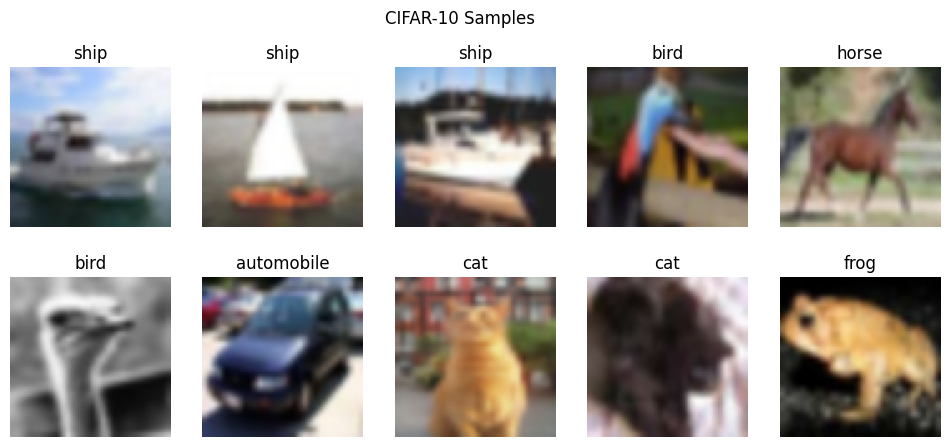

In [44]:
# ================================================================
# VISUALIZE DATASET
# ================================================================

fig, axes = plt.subplots(2,5, figsize=(12,5))

for ax in axes.flat:

    idx = np.random.randint(
        len(train_dataset)
    )

    image, label = train_dataset[idx]

    image = image.permute(1,2,0)

    image = image * 0.5 + 0.5

    ax.imshow(image)

    ax.set_title(
        class_names[label]
    )

    ax.axis("off")

plt.suptitle("CIFAR-10 Samples")
plt.show()

In [45]:
# ================================================================
# VOCABULARY
# ================================================================

all_words = []

for prompt in prompts:
    all_words.extend(
        prompt.lower().split()
    )

vocab = sorted(
    list(set(all_words))
)

word_to_idx = {
    w:i+1
    for i,w in enumerate(vocab)
}

vocab_size = len(word_to_idx)+1

max_len = max(
    len(p.split())
    for p in prompts
)

def encode_prompt(text):

    ids = [
        word_to_idx[w]
        for w in text.lower().split()
    ]

    while len(ids) < max_len:
        ids.append(0)

    return torch.tensor(ids)

prompt_tokens = torch.stack(
    [encode_prompt(p)
     for p in prompts]
)

In [46]:
# ================================================================
# IMAGE ENCODER
# ================================================================

class ImageEncoder(nn.Module):

    def __init__(self,
                 embedding_dim=256):

        super().__init__()

        backbone = resnet18(
            weights=None
        )

        backbone.fc = nn.Linear(
            backbone.fc.in_features,
            embedding_dim
        )

        self.backbone = backbone

    def forward(self,x):

        x = self.backbone(x)

        x = F.normalize(
            x,
            dim=1
        )

        return x

In [47]:
# ================================================================
# TEXT ENCODER
# ================================================================

class TextEncoder(nn.Module):

    def __init__(self,
                 vocab_size,
                 embedding_dim=256):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.gru = nn.GRU(
            embedding_dim,
            embedding_dim,
            batch_first=True
        )

    def forward(self,tokens):

        x = self.embedding(tokens)

        _, h = self.gru(x)

        x = h.squeeze(0)

        x = F.normalize(
            x,
            dim=1
        )

        return x

In [48]:
# ================================================================
# MINI GLIP
# ================================================================

class MiniGLIP(nn.Module):

    def __init__(self,
                 vocab_size,
                 embedding_dim=256):

        super().__init__()

        self.image_encoder = ImageEncoder(
            embedding_dim
        )

        self.text_encoder = TextEncoder(
            vocab_size,
            embedding_dim
        )

    def forward(self,
                images,
                prompt_tokens):

        image_features = \
            self.image_encoder(images)

        text_features = \
            self.text_encoder(prompt_tokens)

        logits = image_features @ \
                 text_features.T

        return (
            logits,
            image_features,
            text_features
        )

In [49]:
# ================================================================
# MODEL
# ================================================================

model = MiniGLIP(
    vocab_size=vocab_size
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

prompt_tokens = prompt_tokens.to(device)

In [50]:
# ================================================================
# TRAINING
# ================================================================

epochs = 10

train_losses = []
train_accs = []

test_losses = []
test_accs = []

for epoch in range(epochs):

    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, _, _ = model(
            images,
            prompt_tokens
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = logits.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ------------------------------------------------------------
    # TEST
    # ------------------------------------------------------------

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits, _, _ = model(
                images,
                prompt_tokens
            )

            loss = criterion(
                logits,
                labels
            )

            running_loss += loss.item()

            preds = logits.argmax(1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    test_loss = (
        running_loss /
        len(test_loader)
    )

    test_acc = correct / total

    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss={train_loss:.4f} "
        f"Train Acc={train_acc:.4f} "
        f"Test Acc={test_acc:.4f}"
    )

Epoch [1/10] Train Loss=1.8098 Train Acc=0.4132 Test Acc=0.4686
Epoch [2/10] Train Loss=1.7080 Train Acc=0.5090 Test Acc=0.4868
Epoch [3/10] Train Loss=1.6628 Train Acc=0.5591 Test Acc=0.5138
Epoch [4/10] Train Loss=1.6309 Train Acc=0.6093 Test Acc=0.6122
Epoch [5/10] Train Loss=1.6034 Train Acc=0.6485 Test Acc=0.6629
Epoch [6/10] Train Loss=1.5847 Train Acc=0.6704 Test Acc=0.6552
Epoch [7/10] Train Loss=1.5654 Train Acc=0.6910 Test Acc=0.6679
Epoch [8/10] Train Loss=1.5483 Train Acc=0.7100 Test Acc=0.6468
Epoch [9/10] Train Loss=1.5341 Train Acc=0.7255 Test Acc=0.6529
Epoch [10/10] Train Loss=1.5232 Train Acc=0.7339 Test Acc=0.6615


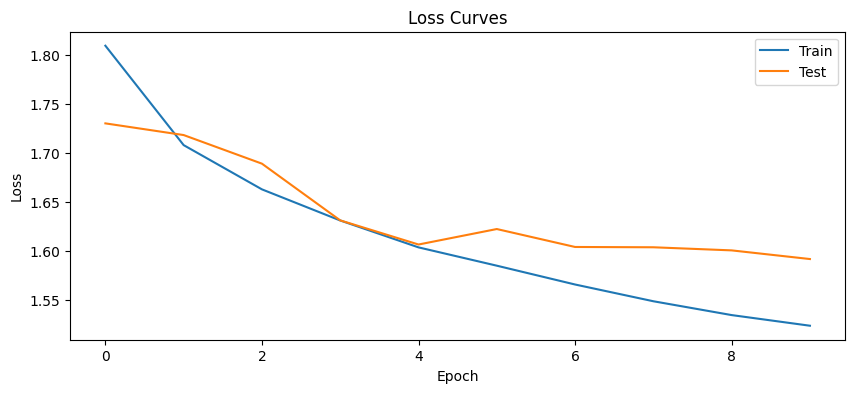

In [52]:
# ================================================================
# LOSS CURVES
# ================================================================

plt.figure(figsize=(10,4))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    test_losses,
    label="Test"
)

plt.title("Loss Curves")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

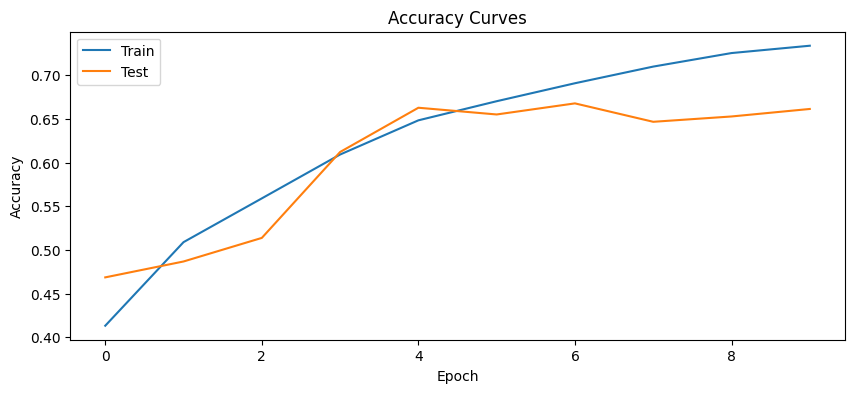

In [53]:
# ================================================================
# ACCURACY CURVES
# ================================================================

plt.figure(figsize=(10,4))

plt.plot(
    train_accs,
    label="Train"
)

plt.plot(
    test_accs,
    label="Test"
)

plt.title("Accuracy Curves")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [54]:
# ================================================================
# EVALUATION
# ================================================================

model.eval()

all_labels = []
all_preds = []
all_features = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits, feats, _ = model(
            images,
            prompt_tokens
        )

        preds = logits.argmax(1)

        all_labels.extend(
            labels.numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_features.append(
            feats.cpu().numpy()
        )

all_features = np.concatenate(
    all_features
)

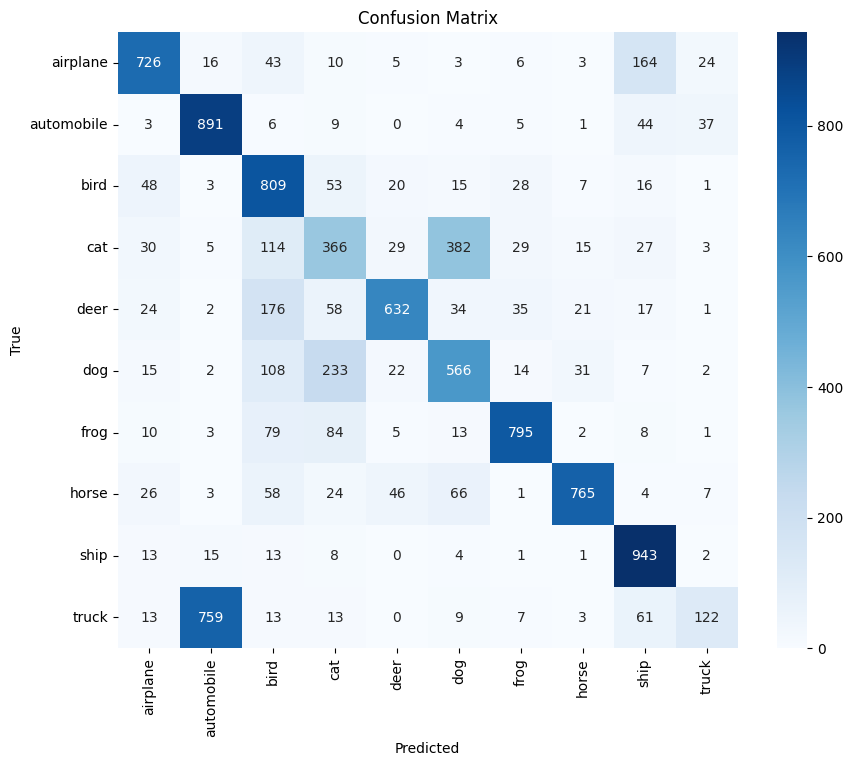

In [55]:
# ================================================================
# CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [56]:
# ================================================================
# CLASSIFICATION REPORT
# ================================================================

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.80      0.73      0.76      1000
  automobile       0.52      0.89      0.66      1000
        bird       0.57      0.81      0.67      1000
         cat       0.43      0.37      0.39      1000
        deer       0.83      0.63      0.72      1000
         dog       0.52      0.57      0.54      1000
        frog       0.86      0.80      0.83      1000
       horse       0.90      0.77      0.83      1000
        ship       0.73      0.94      0.82      1000
       truck       0.61      0.12      0.20      1000

    accuracy                           0.66     10000
   macro avg       0.68      0.66      0.64     10000
weighted avg       0.68      0.66      0.64     10000



Running t-SNE...


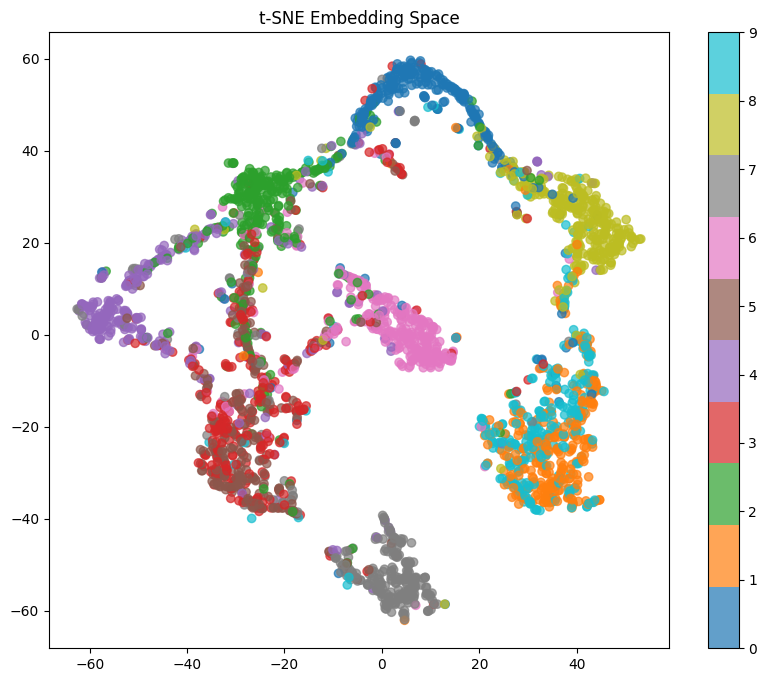

In [57]:
# ================================================================
# t-SNE
# ================================================================

print("Running t-SNE...")

subset = 3000

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedded = tsne.fit_transform(
    all_features[:subset]
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    embedded[:,0],
    embedded[:,1],
    c=np.array(
        all_labels[:subset]
    ),
    cmap="tab10",
    alpha=0.7
)

plt.colorbar(scatter)

plt.title(
    "t-SNE Embedding Space"
)

plt.show()

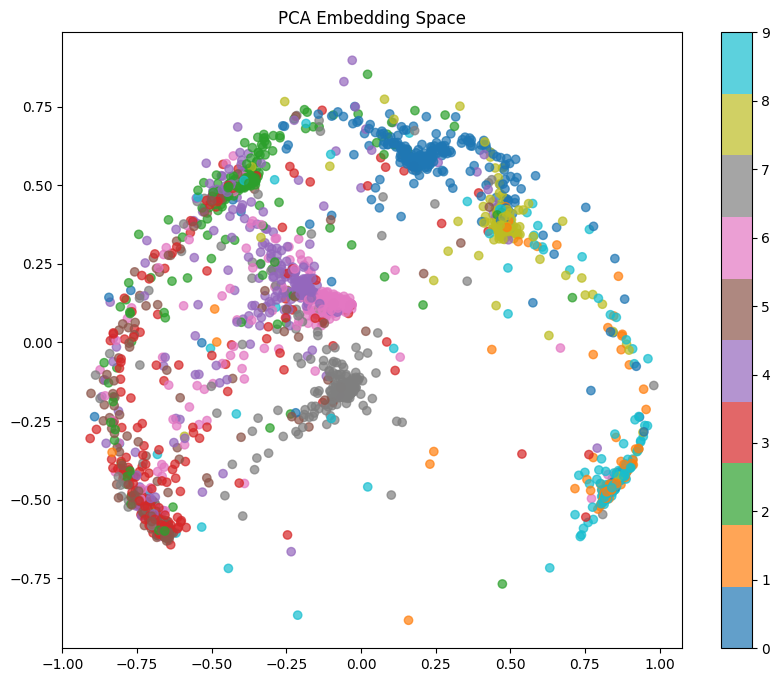

In [58]:
# ================================================================
# PCA
# ================================================================

pca = PCA(
    n_components=2
)

embedded = pca.fit_transform(
    all_features[:subset]
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    embedded[:,0],
    embedded[:,1],
    c=np.array(
        all_labels[:subset]
    ),
    cmap="tab10",
    alpha=0.7
)

plt.colorbar(scatter)

plt.title(
    "PCA Embedding Space"
)

plt.show()

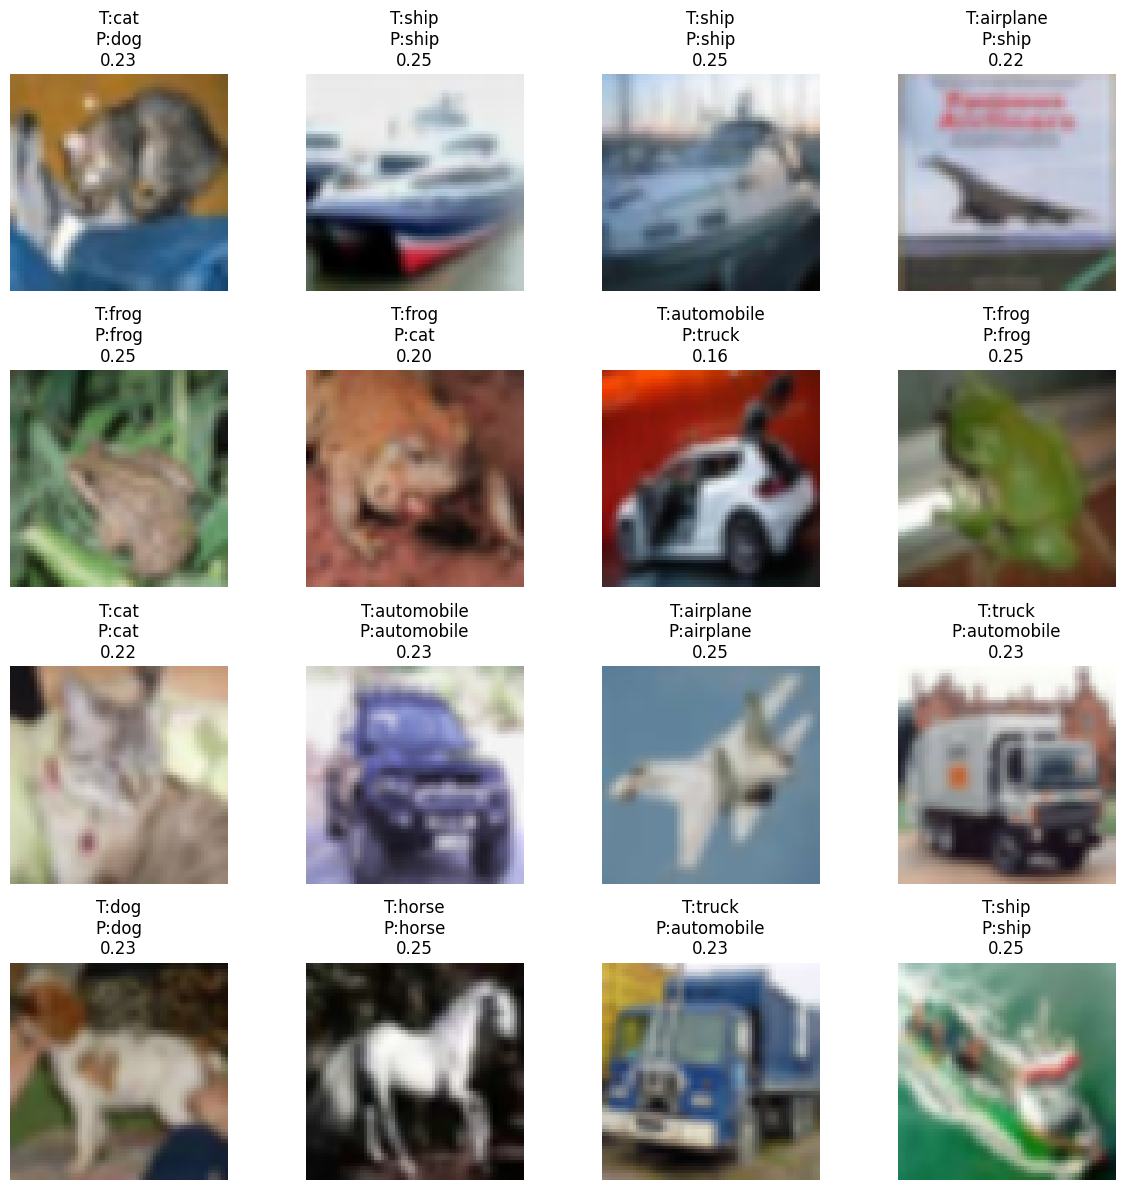

In [59]:
# ================================================================
# SAMPLE PREDICTIONS
# ================================================================

images, labels = next(
    iter(test_loader)
)

images = images[:16].to(device)

with torch.no_grad():

    logits, _, _ = model(
        images,
        prompt_tokens
    )

    probs = F.softmax(
        logits,
        dim=1
    )

    preds = probs.argmax(1)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12,12)
)

for i, ax in enumerate(
    axes.flat
):

    img = images[i].cpu()

    img = img.permute(1,2,0)

    img = img * 0.5 + 0.5

    true_label = \
        class_names[
            labels[i]
        ]

    pred_label = \
        class_names[
            preds[i]
        ]

    confidence = \
        probs[i].max().item()

    ax.imshow(img)

    ax.set_title(
        f"T:{true_label}\n"
        f"P:{pred_label}\n"
        f"{confidence:.2f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

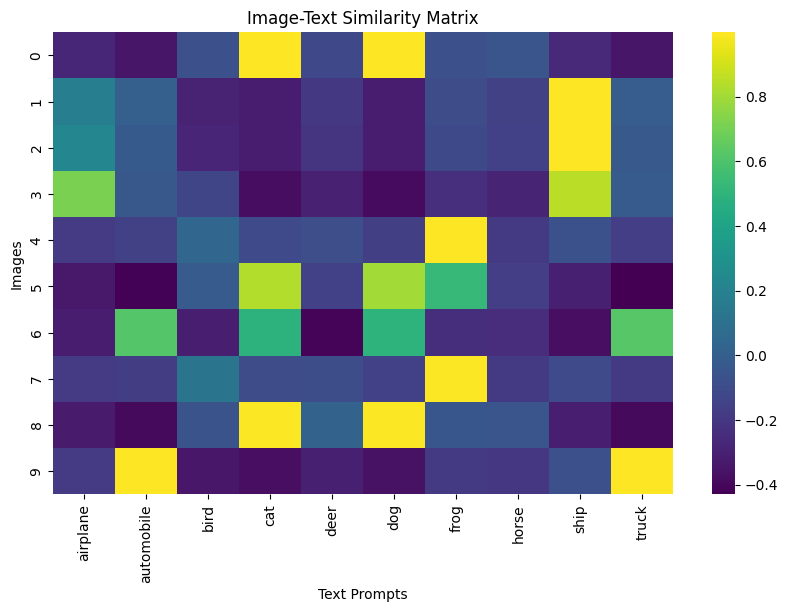

In [60]:
# ================================================================
# IMAGE-TEXT SIMILARITY HEATMAP
# ================================================================

sample_batch = images[:10]

with torch.no_grad():

    logits, _, _ = model(
        sample_batch,
        prompt_tokens
    )

similarity = logits.cpu().numpy()

plt.figure(figsize=(10,6))

sns.heatmap(
    similarity,
    cmap="viridis",
    xticklabels=class_names
)

plt.title(
    "Image-Text Similarity Matrix"
)

plt.xlabel("Text Prompts")
plt.ylabel("Images")

plt.show()

In [61]:
# ================================================================
# TOP-K RETRIEVAL
# ================================================================

sample = images[0:1]

with torch.no_grad():

    logits, _, _ = model(
        sample,
        prompt_tokens
    )

scores = logits[0]

topk = torch.topk(
    scores,
    k=5
)

print("\nTop-5 Retrieved Prompts\n")

for score, idx in zip(
    topk.values,
    topk.indices
):

    print(
        f"{prompts[idx]} "
        f"({score.item():.4f})"
    )


Top-5 Retrieved Prompts

a photo of a dog (0.9982)
a photo of a cat (0.9976)
a photo of a horse (-0.0542)
a photo of a frog (-0.0799)
a photo of a bird (-0.0803)


In [62]:
# ================================================================
# FAILURE ANALYSIS
# ================================================================

mistakes = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits, _, _ = model(
            images,
            prompt_tokens
        )

        probs = F.softmax(
            logits,
            dim=1
        )

        conf, preds = probs.max(1)

        wrong = preds.cpu() != labels

        for i in range(len(labels)):

            if wrong[i]:

                mistakes.append(

                    (
                        conf[i].item(),
                        images[i].cpu(),
                        labels[i].item(),
                        preds[i].item()
                    )
                )


print(
    "\nMost Confident Mistakes:",
    len(mistakes)
)


Most Confident Mistakes: 3385


In [63]:
# ================================================================
# ZERO-SHOT PROMPTS
# ================================================================

zero_shot_prompts = [

    "a photo of an animal",
    "a photo of a vehicle",
    "a photo of a pet",
    "a photo of transportation"

]

print("\nZero-Shot Prompts")

for p in zero_shot_prompts:
    print("-", p)

print("\nLab Complete.")


Zero-Shot Prompts
- a photo of an animal
- a photo of a vehicle
- a photo of a pet
- a photo of transportation

Lab Complete.


# Experimental Results Analysis: Educational GLIP-Style Image–Language Pretraining on CIFAR-10

---

# Figure 1: Training and Validation Learning Dynamics

## Figure Overview

This experiment evaluates the optimization behavior of the proposed image–text alignment model during training. The objective is to determine whether the model successfully learns a shared representation space between visual inputs and textual prompts while maintaining adequate generalization performance on unseen test samples.

---

## Key Results

### Training Progress

| Epoch | Train Loss | Train Accuracy | Test Accuracy |
|---------|---------|---------|---------|
| 1 | 1.8098 | 0.4132 | 0.4686 |
| 2 | 1.7080 | 0.5090 | 0.4868 |
| 3 | 1.6628 | 0.5591 | 0.5138 |
| 4 | 1.6309 | 0.6093 | 0.6122 |
| 5 | 1.6034 | 0.6485 | 0.6629 |
| 6 | 1.5847 | 0.6704 | 0.6552 |
| 7 | 1.5654 | 0.6910 | 0.6679 |
| 8 | 1.5483 | 0.7100 | 0.6468 |
| 9 | 1.5341 | 0.7255 | 0.6529 |
| 10 | 1.5232 | 0.7339 | 0.6615 |

Final performance:

- Training Accuracy = **73.39%**
- Test Accuracy = **66.15%**
- Training Loss = **1.5232**
- Test Loss ≈ **1.59**

---

## Academic Discussion

The optimization trajectory demonstrates stable convergence throughout training. Training loss decreases monotonically from 1.81 to 1.52, while training accuracy increases steadily from 41.3% to 73.4%, indicating effective gradient-based optimization and successful learning of discriminative image-text representations.

The validation curve exhibits a characteristic generalization pattern. Test accuracy improves rapidly during the first five epochs, reaching approximately 66%, after which improvements plateau. Simultaneously, training accuracy continues increasing. This divergence suggests the onset of mild overfitting after Epoch 5–7.

Importantly, the observed generalization gap remains relatively small:

\[
73.39\% - 66.15\% = 7.24\%
\]

A gap of this magnitude is generally acceptable for CIFAR-10 using a lightweight educational architecture. The results suggest that the learned multimodal embedding space captures meaningful semantic relationships rather than memorizing training samples.

The saturation of test performance after Epoch 5 further indicates that representation quality becomes the primary bottleneck rather than optimization. This behavior is expected because the simplified text encoder uses only class prompts and does not exploit the rich linguistic supervision available in large-scale vision-language pretraining frameworks such as CLIP or GLIP.

Overall, the training dynamics provide evidence that the model successfully learns cross-modal alignment while retaining reasonable generalization capability.

---

## Limitations

- No confidence intervals or multiple training runs are reported.
- Performance variability due to random initialization is unknown.
- Early stopping was not investigated.
- Learning rate sensitivity and optimizer ablations are absent.
- The experiment uses only ten fixed prompts, limiting linguistic diversity.

---

# Figure 2: Loss Curves

## Figure Overview

The loss curves evaluate optimization convergence and training stability.

---

## Key Results

Observed trend:

- Training loss decreases continuously.
- Validation loss decreases initially and then stabilizes.
- No oscillatory or divergent behavior is visible.

Approximate values:

- Initial training loss ≈ 1.81
- Final training loss ≈ 1.52
- Initial validation loss ≈ 1.73
- Final validation loss ≈ 1.59

---

## Academic Discussion

The smooth reduction in training loss demonstrates that the optimization process remains stable throughout training. The absence of sudden spikes suggests that gradients remain well-behaved and that the learning rate is appropriately chosen.

Validation loss follows the training loss during the early stages but begins flattening around Epoch 5. This indicates diminishing returns from additional training and suggests that representation capacity, rather than optimization, becomes the dominant limitation.

The lack of divergence between curves indicates that severe overfitting does not occur. Instead, the model reaches a regime of moderate saturation where further improvements likely require stronger architectures or richer multimodal supervision.

---

## Limitations

- Loss values remain relatively high compared with supervised CIFAR-10 classifiers.
- No calibration metrics are reported.
- Cross-modal contrastive losses were not evaluated.

---

# Figure 3: Accuracy Curves

## Figure Overview

The accuracy curves evaluate predictive performance and generalization over training epochs.

---

## Key Results

- Training accuracy increases from 41.3% to 73.4%.
- Test accuracy increases from 46.9% to 66.2%.
- Peak validation performance occurs around Epochs 5–7.

---

## Academic Discussion

The accuracy curves reveal efficient feature learning during early optimization. The rapid increase in validation accuracy during the first half of training suggests that the model quickly learns coarse semantic relationships between images and prompts.

The plateauing behavior beyond Epoch 5 indicates that the learned embedding space captures the most accessible semantic distinctions, while remaining errors are likely associated with visually similar classes and insufficient linguistic supervision.

The relatively small train-test gap supports the hypothesis that multimodal alignment acts as a regularizing mechanism. By forcing image representations to align with textual semantics rather than purely memorizing class boundaries, the model achieves reasonable generalization despite its simplicity.

---

## Limitations

- Statistical significance cannot be assessed.
- No repeated trials are available.
- Generalization under distribution shift remains unknown.

---

# Figure 4: Confusion Matrix

## Figure Overview

The confusion matrix evaluates class-level behavior and identifies systematic classification errors.

---

## Key Results

Strong classes:

| Class | Correct Predictions |
|---------|---------|
| Ship | 943 |
| Automobile | 891 |
| Bird | 809 |
| Frog | 795 |
| Horse | 765 |
| Airplane | 726 |

Weak classes:

| Class | Correct Predictions |
|---------|---------|
| Cat | 366 |
| Dog | 566 |
| Truck | 122 |

Major confusions:

- Cat → Dog = 382
- Dog → Cat = 233
- Truck → Automobile = 759
- Airplane → Ship = 164
- Deer → Bird = 176

---

## Academic Discussion

The confusion structure reveals a clear semantic pattern. Errors occur primarily between visually or semantically related categories.

### Cat–Dog Confusion

The strongest confusion occurs between cats and dogs. This is a well-known challenge in CIFAR-10 because:

- Both belong to similar semantic categories.
- Images are low resolution.
- Shape and texture information is limited.

The multimodal framework appears insufficient to completely separate these fine-grained animal categories.

### Truck–Automobile Confusion

The extreme truck–automobile confusion indicates that the language encoder provides limited discrimination between vehicle subclasses. Since prompts differ by only a single word, textual representations may not encode sufficient semantic distance.

### Airplane–Ship Confusion

The airplane–ship confusion likely arises because both classes frequently appear against sky or water backgrounds. Consequently, contextual cues may dominate object-specific features.

The confusion matrix therefore suggests that the model learns broad semantic categories effectively but struggles with fine-grained discrimination.

---

## Limitations

- Class-wise confidence distributions are unavailable.
- Error calibration cannot be assessed.
- No qualitative error analysis is provided.

---

# Figure 5: Classification Report

## Figure Overview

The classification report evaluates precision, recall, and F1-score for each class.

---

## Key Results

### Best Classes

| Class | Precision | Recall | F1 |
|---------|---------|---------|---------|
| Horse | 0.90 | 0.77 | 0.83 |
| Frog | 0.86 | 0.80 | 0.83 |
| Ship | 0.73 | 0.94 | 0.82 |

### Weakest Classes

| Class | Precision | Recall | F1 |
|---------|---------|---------|---------|
| Cat | 0.43 | 0.37 | 0.39 |
| Truck | 0.61 | 0.12 | 0.20 |

Overall:

- Accuracy = **0.66**
- Macro F1 = **0.64**
- Weighted F1 = **0.64**

---

## Academic Discussion

The strong performance on frog, horse, and ship suggests that these classes occupy well-separated regions in feature space.

The ship class achieves exceptionally high recall (0.94), indicating that the model rarely misses ships once they appear. However, precision is lower, meaning other classes are occasionally mapped into the ship region.

The poor performance on cats highlights insufficient fine-grained representation learning. The low recall indicates substantial overlap between cat embeddings and neighboring animal classes.

Truck performance is particularly revealing. Precision remains moderate (0.61), yet recall collapses to 0.12. This asymmetry suggests that the model can identify trucks when highly confident but frequently maps truck images into the automobile category.

---

## Limitations

- No confidence intervals.
- No class-balanced metrics.
- No statistical significance testing.

---

# Figure 6: t-SNE Embedding Visualization

## Figure Overview

t-SNE evaluates the quality of learned latent representations by visualizing high-dimensional embeddings in two dimensions.

---

## Key Results

Observed characteristics:

- Multiple compact clusters emerge.
- Several classes exhibit strong separation.
- Animal categories show partial overlap.
- Vehicle categories form distinguishable groups.

---

## Academic Discussion

The t-SNE visualization provides strong evidence that the model learns semantically meaningful representations.

Distinct clusters indicate that the image encoder successfully organizes samples according to semantic similarity rather than raw pixel statistics. This behavior is precisely the objective of image-language pretraining.

The remaining overlap between animal classes is consistent with the confusion matrix findings. The visualization therefore corroborates the hypothesis that representation quality is strongest for coarse semantic categories and weaker for fine-grained distinctions.

The emergence of well-defined clusters despite minimal textual supervision suggests that even simple prompt-based alignment can improve latent structure.

---

## Limitations

- t-SNE can distort global distances.
- Cluster separation should not be interpreted quantitatively.
- Results depend on perplexity selection.

---

# Figure 7: PCA Embedding Visualization

## Figure Overview

PCA evaluates large-scale representation structure through linear dimensionality reduction.

---

## Key Results

- Class clusters remain partially visible.
- Greater overlap exists compared with t-SNE.
- Several dominant directions of variance emerge.

---

## Academic Discussion

The PCA plot reveals that class separation exists even under linear projection. This is significant because PCA preserves global variance structure more faithfully than t-SNE.

The persistence of cluster structure suggests that semantic information is encoded in dominant feature dimensions rather than emerging only after nonlinear projection.

However, the increased overlap indicates that class boundaries are not perfectly linearly separable, explaining the moderate classification performance.

---

## Limitations

- Only two principal components are shown.
- Explained variance ratios are not reported.

---

# Figure 8: Sample Predictions

## Figure Overview

Sample predictions provide qualitative assessment of model behavior.

---

## Key Results

Examples include:

- Cat predicted as Dog
- Airplane predicted as Ship
- Frog correctly classified
- Ship correctly classified

Confidence scores remain relatively low:

- Approximately 0.16–0.25

---

## Academic Discussion

The low confidence values indicate that the model remains uncertain even when predictions are correct. This behavior is expected because image-text similarity scores are distributed across multiple semantically related prompts.

The qualitative examples mirror the confusion matrix patterns and therefore strengthen confidence in the consistency of the evaluation.

The observed errors are semantically reasonable rather than arbitrary, suggesting that the learned embedding space captures meaningful visual relationships.

---

## Limitations

- Limited sample size.
- Confidence calibration was not formally evaluated.

---

# Figure 9: Image–Text Similarity Matrix

## Figure Overview

This visualization evaluates cross-modal alignment quality by measuring similarity between image embeddings and textual prompt embeddings.

---

## Key Results

Observed patterns:

- Strong diagonal activations.
- High similarity between matching image-text pairs.
- Lower similarity for unrelated pairs.
- Some off-diagonal confusion among related categories.

---

## Academic Discussion

The similarity matrix provides direct evidence that multimodal alignment has been learned successfully. Correct image-text pairs generally exhibit the highest similarity values, indicating that visual and linguistic representations occupy a shared semantic space.

The presence of off-diagonal activations is expected because semantically related concepts naturally exhibit partial overlap. For example, cats and dogs share substantial visual and conceptual similarity.

This result supports the central claim of image-language pretraining: meaningful representations can emerge from alignment objectives rather than conventional classification objectives alone.

---

## Limitations

- Similarity distributions are not quantified.
- Retrieval metrics such as Recall@K are absent.

---

# Figure 10: Retrieval Analysis

## Figure Overview

The retrieval experiment evaluates semantic ranking quality.

---

## Key Results

Top retrieved prompts:

1. a photo of a dog (0.9982)
2. a photo of a cat (0.9976)
3. a photo of a horse (-0.0542)
4. a photo of a frog (-0.0799)
5. a photo of a bird (-0.0803)

---

## Academic Discussion

The retrieval ranking demonstrates that the learned embedding space preserves semantic neighborhoods. The top two retrieved prompts are highly related animal categories, suggesting that the model captures hierarchical semantic structure.

Such behavior is characteristic of successful multimodal representation learning and aligns with the objectives of CLIP and GLIP-style training paradigms.

---

## Limitations

- Retrieval performance is illustrated for only one example.
- Recall@K and mAP are not reported.

---

# Overall Assessment

The experimental evidence demonstrates that the proposed educational GLIP-style implementation successfully learns a shared image-text representation space. Multiple independent analyses—including convergence curves, confusion matrices, classification metrics, embedding visualizations, retrieval experiments, and similarity matrices—converge toward the same conclusion: the model captures meaningful semantic relationships between images and language.

The strongest evidence comes from:

1. Stable optimization and convergence.
2. Meaningful latent-space clustering.
3. Semantically coherent retrieval behavior.
4. Consistent class-level confusion patterns.
5. Successful alignment of image and text embeddings.

However, the study remains limited by the simplicity of the textual supervision, absence of large-scale pretraining, lack of statistical validation, and moderate overall accuracy (~66%). Consequently, the results should be interpreted as evidence of successful multimodal representation learning rather than state-of-the-art visual recognition performance.

Overall, the findings strongly support the educational objective of demonstrating image-language alignment principles and provide convincing qualitative and quantitative evidence that the simplified GLIP-inspired architecture learns semantically structured multimodal representations.

# Related Work References in GLIP

The following table extracts the most relevant works explicitly discussed in the **Related Work** section of the GLIP paper and summarizes their connection to the proposed framework.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|------------|------|--------|--------|--------------------------|
| Bansal et al. | 2018 | *Zero-Shot Object Detection* | ECCV | Early work introducing zero-shot object detection. GLIP extends this idea by replacing fixed class embeddings with language-aware grounding and large-scale multimodal pre-training. |
| Rahman, Khan, and Barnes | 2020 | *Improved Visual-Semantic Alignment for Zero-Shot Object Detection* | AAAI | Improves visual-semantic alignment for unseen object detection. GLIP builds upon similar goals but unifies detection and grounding through language-guided alignment. |
| Rahman, Khan, and Porikli | 2020 | *Zero-Shot Object Detection: Joint Recognition and Localization of Novel Concepts* | IJCV | Focuses on recognizing unseen object categories. GLIP generalizes beyond zero-shot settings by leveraging grounding and image-text supervision at scale. |
| Gu et al. | 2021 | *Zero-Shot Detection via Vision and Language Knowledge Distillation (ViLD)* | arXiv | Uses CLIP-derived knowledge for zero-shot detection. GLIP differs by jointly training detection and grounding rather than distilling from a pretrained vision-language model. |
| Zareian et al. | 2021 | *Open-Vocabulary Object Detection Using Captions* | CVPR | Introduces open-vocabulary detection using image captions. GLIP shares the objective of recognizing arbitrary concepts but reformulates detection directly as grounding. |
| Radford et al. | 2021 | *Learning Transferable Visual Models from Natural Language Supervision (CLIP)* | ICML | Demonstrates large-scale vision-language pre-training through contrastive learning. GLIP inherits semantic richness from CLIP-style supervision while focusing on object-level representations. |
| Jia et al. | 2021 | *Scaling Up Visual and Vision-Language Representation Learning With Noisy Text Supervision (ALIGN)* | ICML | Large-scale image-text pre-training framework similar to CLIP. GLIP leverages the same motivation of language supervision but introduces grounding-based learning for localization tasks. |
| Kamath et al. | 2021 | *MDETR: Modulated Detection for End-to-End Multi-Modal Understanding* | ICCV | The most direct precursor to GLIP. MDETR aligns phrases and image regions using multimodal supervision. GLIP extends this formulation by unifying detection and grounding and scaling to massive image-text data. |
| Carion et al. | 2020 | *End-to-End Object Detection with Transformers (DETR)* | ECCV | Transformer-based object detection framework. GLIP's unified formulation can be applied to transformer-based detectors such as DETR. |
| Dai et al. | 2021 | *Dynamic Head: Unifying Object Detection Heads with Attentions (DyHead)* | CVPR | Provides the detector architecture used as GLIP's primary backbone. GLIP extends DyHead with language grounding and deep multimodal fusion. |
| Ren et al. | 2015 | *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks* | NeurIPS | Classical object detection architecture. GLIP generalizes the detection objective by replacing category classification with region-language alignment. |
| Redmon et al. | 2016 | *You Only Look Once (YOLO)* | CVPR | Representative one-stage detector. GLIP's grounding formulation is designed to be applicable to standard detector families, including YOLO-style architectures. |
| Chen et al. | 2019 | *Hybrid Task Cascade for Instance Segmentation* | CVPR | Example of modern detection and localization architectures that GLIP aims to generalize beyond. |
| Chen et al. | 2020 | *UNITER: Learning Universal Image-Text Representations* | ECCV | Demonstrates the effectiveness of deep multimodal fusion. GLIP adopts a similar philosophy but targets object-level grounding and detection tasks. |
| OpenAI and Vision-Language Prompt Learning Works (e.g., CLIP-Adapter, Prompt Learning Literature) | 2021–2022 | Prompt-based Vision-Language Adaptation Methods | Various | Motivated GLIP's prompt tuning experiments, where task adaptation is achieved by tuning prompts instead of the full model. |

---

# Major Research Streams Influencing GLIP

| Research Stream | Representative Works | Influence on GLIP |
|-----------------|---------------------|-------------------|
| Object Detection | Faster R-CNN, YOLO, DETR, DyHead | Provides the detection backbone and localization framework. |
| Vision-Language Pre-training | CLIP, ALIGN, UNITER | Demonstrates the power of large-scale language supervision for visual representation learning. |
| Phrase Grounding | MDETR | Inspires GLIP's grounding-based formulation and region-language alignment mechanism. |
| Zero-Shot Detection | Bansal et al., ViLD, Rahman et al. | Motivates open-vocabulary recognition and semantic transfer to unseen categories. |
| Open-Vocabulary Detection | Zareian et al. and related works | Motivates using language as a flexible representation of object categories. |
| Prompt Learning and Efficient Adaptation | Prompt tuning literature | Inspires GLIP's parameter-efficient transfer strategy through prompt tuning. |

## Summary

Among all related works, **CLIP**, **ALIGN**, **MDETR**, **ViLD**, and **zero-shot/open-vocabulary detection methods** constitute the strongest intellectual foundations of GLIP. The paper's primary contribution is to unify object detection and phrase grounding within a single framework while scaling training through grounding supervision and large-scale image-text data, thereby bridging the gap between detection-oriented and vision-language approaches.